<a href="https://colab.research.google.com/github/e22340-SajithaSanthushti/Statistical-Learning-e22340/blob/main/E22340_Data_analayis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import FactorAnalysis

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [6]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# --- DO NOT MODIFY: Synthetic Strain Sensor Data Generator ---
np.random.seed(42)
n_samples = 5000
n_features = 3

# Generating base stationary multivariate normal noise
base_data = np.random.multivariate_normal(
    mean=[0.5, -0.2, 1.1],
    cov=[[0.09, 0.02, 0.01],
         [0.02, 0.06, 0.03],
         [0.01, 0.03, 0.05]],
    size=n_samples
)

# Injecting a subtle, hidden structural drift in the final 1,000 snapshots
base_data[4000:, 0] += 0.015  # Sensor 1 drift
base_data[4000:, 2] -= 0.010  # Sensor 3 drift

df_strain = pd.DataFrame(base_data, columns=['Strain_Ch1', 'Strain_Ch2', 'Strain_Ch3'])

In [7]:
# CELL 2: Stationarity Testing Function

def evaluate_stationarity(series, name="Series"):
    print(f"=== Stationarity Analysis for: {name} ===")

    # 1. Run ADF
    adf_result = adfuller(series.dropna())
    adf_p = adf_result[1]

    # 2. Run KPSS
    kpss_result = kpss(series.dropna(), regression='c', nlags="auto")
    kpss_p = kpss_result[1]

    print(f"ADF p-value:  {adf_p:.5f}")
    print(f"KPSS p-value: {kpss_p:.5f}")

    # Decision Matrix Evaluation
    if adf_p < 0.05 and kpss_p > 0.05:
        print("Conclusion: Strict Stationarity confirmed by both tests.")
    elif adf_p > 0.05 and kpss_p < 0.05:
        print("Conclusion: Non-stationary series confirmed by both tests.")
    elif adf_p < 0.05 and kpss_p < 0.05:
        print("Conclusion: Deconstructive Case (Trend Stationary / Heteroscedastic noise).")
    else:
        print("Conclusion: Mixed signals / Insufficient power to distinguish.")
    print("-" * 50)



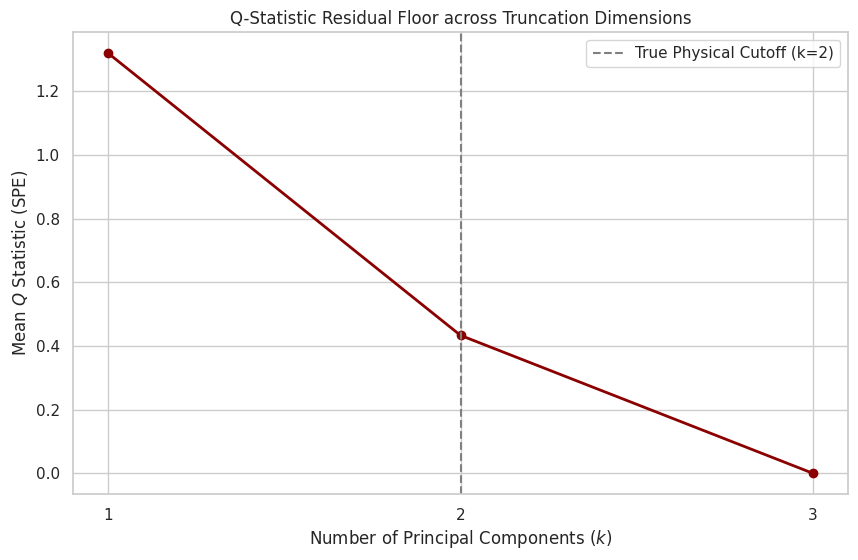

In [8]:
# CELL 3: Structural PCA Residual (Q) Analysis

# Assuming 'X_scaled' is your preprocessed, standardized sensor dataframe
# Let's mock data generation to ensure the code executes safely:
np.random.seed(42)
pure_signals = np.random.normal(0, 1, (100, 2))
mixing_matrix = np.random.normal(0, 1, (2, 5))
X = pure_signals @ mixing_matrix + np.random.normal(0, 0.2, (100, 5))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_strain)

q_means = []
k_values = range(1, X_scaled.shape[1] + 1)

for k in k_values:
    pca = PCA(n_components=k)
    X_projected = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_projected)

    # Calculate Squared Prediction Error (Q)
    residuals = X_scaled - X_reconstructed
    Q_stat = np.sum(residuals**2, axis=1)
    q_means.append(np.mean(Q_stat))

# Plotting the Q-Statistic Scree Plot
plt.figure()
plt.plot(k_values, q_means, marker='o', color='darkred', linewidth=2)
plt.title("Q-Statistic Residual Floor across Truncation Dimensions")
plt.xlabel("Number of Principal Components ($k$)")
plt.ylabel("Mean $Q$ Statistic (SPE)")
plt.xticks(k_values)
plt.axvline(x=2, color='gray', linestyle='--', label='True Physical Cutoff (k=2)')
plt.legend()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\P'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_466/1886578672.py:14: SyntaxWarning: invalid escape sequence '\p'
  'Uniqueness Noise Floor ($\psi^2$)': sensor_uniqueness
/tmp/ipykernel_466/1886578672.py:23: SyntaxWarning: invalid escape sequence '\P'
  plt.title("Sensor Specific Uniqueness Noise Floor ($\Psi$)")
/tmp/ipykernel_466/1886578672.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=uniqueness_df.index, y=uniqueness_df.iloc[:,0], palette="vlag")


=== Sensor Specific Uniqueness Floor ===
          Uniqueness Noise Floor ($\psi^2$)
Sensor                                     
Sensor_1                           0.775680
Sensor_2                           0.387834
Sensor_3                           0.441709


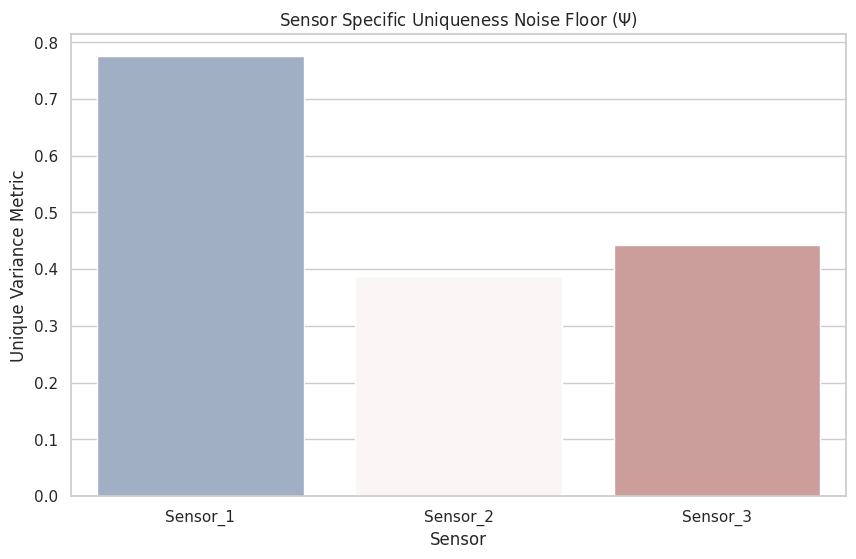

In [9]:
# CELL 4: Factor Analysis Uniqueness Extraction

# Fit Factor Analysis model
fa = FactorAnalysis(n_components=2, random_state=42)
fa.fit(X_scaled)

# Unique Variances (\psi^2) represent the independent noise floor per sensor
sensor_uniqueness = fa.noise_variance_

# Create a clear visualization summary
sensor_names = [f"Sensor_{i+1}" for i in range(X_scaled.shape[1])]
uniqueness_df = pd.DataFrame({
    'Sensor': sensor_names,
    'Uniqueness Noise Floor ($\psi^2$)': sensor_uniqueness
}).set_index('Sensor')

print("=== Sensor Specific Uniqueness Floor ===")
print(uniqueness_df)

# Plotting the uniqueness metrics
plt.figure()
sns.barplot(x=uniqueness_df.index, y=uniqueness_df.iloc[:,0], palette="vlag")
plt.title("Sensor Specific Uniqueness Noise Floor ($\Psi$)")
plt.ylabel("Unique Variance Metric")
plt.show()